# Downloading data from Monitor My Watershed using the TSV Endpoint

This notebook demonstrates how to use the Time Series Visualization (TSV) endpoint to extract data from Monitor My Watershed.
This endpoint serves as a temporary access point between the shut-down of the WoFpy service and the development of a more efficient and permanent service.

To get data from Monitor My Watershed, we need to make 2 post requests to https://monitormywatershed.org/dataloader/ajax/.
The post is sent as form data, sending the key `request_data` with a JSON object as the value.
In the JSON object is the method and other request data.

- In the first POST request, we specify specifying the method `get_sampling_feature_metadata` and the sampling feature code:

  - The JSON looks like this:
    ```json
    {
      "method": "get_sampling_feature_metadata",
      "sampling_feature_code": "YOUR_SITE_CODE"
    }
    ```
  - The full request looks like this (in CURL)
    ```sh
        curl --location 'https://monitormywatershed.org/dataloader/ajax/' \
             --form 'request_data="{\"method\": \"get_sampling_feature_metadata\",\"sampling_feature_code\": \"YOUR_SITE_CODE\"}"'
    ```
  - The response from this first POST request is a JSON containing a list of results available for the sampling feature.
    By parsing the JSON, you can get the result ID for the UUID or variable code that you're interested in.

- In the second post request we specify specifying the method `get_result_timeseries`, the result ID and the date range (if desired):
  - If you want the entire range of data, you do not need to specify the start and end date. - _If you request the entire date range, the response may take a **LONG** time to appear!!_ - NOTE: The result ID is an arbitrary number and **may change at any time**.  
    You should get the correct result id each time using the first POST request.
  - The JSON looks like this:
    ```json
    {
      "method": "get_result_timeseries",
      "resultid": "RESULT_NUMBER_FROM_FIRST_REQUEST",
      "start_date": "2024-03-01T00:00:00-05:00",
      "end_date": "2024-03-15T00:00:00-05:00"
    }
    ```
  - The full request looks like this (in CURL)
    ```sh
      curl --location 'https://monitormywatershed.org/dataloader/ajax/' \
           --header 'origin: https://monitormywatershed.org' \
           --header 'Referer: https://monitormywatershed.org/tsv/' \
           --form 'request_data="{\"method\": \"get_result_timeseries\", \"resultid\": \"563\", \"start_date\": \"2024-03-01T00:00:00-05:00\", \"end_date\": \"2024-03-15T00:00:00-05:00\"}"'
    ```
  - The response from this second POST request is a JSON containing a lists of value id's, data values, timestamps (as a unix time - the number of seconds from January 1, 1970), and the UTC offset of the data.
    This JSON can be parsed into a data frame or any format you want.


# Making the requests in R

From here, is example code of a function to run the two post requests using the R programming language

## Step 1: Import libraries; set options

This example uses [HTTR2](https://httr2.r-lib.org/) for the web request, [jsonlite](https://www.rdocumentation.org/packages/jsonlite/versions/1.8.8) for JSON parsing, [clock](https://clock.r-lib.org/index.html) for timezone handing, and [ggplot2](https://ggplot2.tidyverse.org/) for plotting.


In [1]:
library(httr2)
library(jsonlite)
library(clock)
library(ggplot2)

options(max.print = 10)
Sys.setenv(TZ = "Etc/GMT+5")
# NOTE: The time zone "Etc/GMT+5" is actually -5!


## Step 2: A function to get Monitor My Watershed data

This function takes care of the two step process of getting data from the TSV endpoint of Monitor My Watershed.
Within the function, first the site code is used to extract metadata about the site, including the internal id corresponding to each variable code and UUID.
Then, using the internal id, we pull up the actual data.
After pulling in the data, we combine the millisecond timestamp and timezone into a timezone-aware timestamp using a text combination and the clock library.
The final return is a data frame with the timestamp, data value, and utc offset.


In [ ]:
# Function to get data from Monitor My Watershed
get_monitormw_data <- function(
    site_code,
    uuid,
    variable_code,
    start_date,
    end_date) {
  # the TSV endpoint URL
  tsv_data_url <- "https://monitormywatershed.org/dataloader/ajax/"

  # create the json which we will send as the request for site metadata
  metadata_request_data <- list(
    "method" = "get_sampling_feature_metadata",
    "sampling_feature_code" = site_code
  ) |>
    toJSON(auto_unbox = TRUE)
  metadata_request_data

  # Create the request to get the metadata
  metadata_req <- request(tsv_data_url) |>
    # Change the HTTP method to POST
    req_method("POST") |>
    # Add a body
    req_body_form(request_data = metadata_request_data) |>
    # Set up automatic retry if the request fails
    req_retry(max_tries = 5) |>
    # Set the timeout really high
    req_timeout(120) |>
    # Use req_headers() to add origin and referer headers
    req_headers(Origin = "https://monitormywatershed.org") |>
    req_headers(Referer = "https://monitormywatershed.org/tsv/")

  # make the request
  metadata_resp <- req_perform(metadata_req, verbosity = 0)

  # read the metadata response
  site_datasets <- fromJSON(resp_body_json(metadata_resp))

  # subset out the result number of interest
  if (missing(uuid) && !missing(variable_code)) {
    relevant_result <- subset(site_datasets, variablecode == variable_code)$"resultid"[1]
  } else if (!missing(uuid) && missing(variable_code)) {
    relevant_result <- subset(site_datasets, resultuuid == uuid)$"resultid"[1]
  } else {
    stop("Either a UUID or variable code must be specified!")
  }


  # create the json which we will send as the request for specific time series data
  data_request_data <- list(
    "method" = "get_result_timeseries",
    "resultid" = as.character(relevant_result)
  )
  # add the start date, if specified
  if (!missing(start_date)) {
    data_request_data <- c(data_request_data, "start_date" = start_date)
  }
  # add the end date, if specified
  if (!missing(end_date)) {
    data_request_data <- c(data_request_data, "end_date" = end_date)
  }
  data_request_data <- toJSON(data_request_data, auto_unbox = TRUE)

  # Create the request to get the actual data
  ts_data_req <- request(tsv_data_url) |>
    # Change the HTTP method to POST
    req_method("POST") |>
    # Add a body
    req_body_form(request_data = data_request_data) |>
    # Set up automatic retry if the request fails
    req_retry(max_tries = 5) |>
    # Set the timeout really high
    req_timeout(120) |>
    # Use req_headers() to add origin and referer headers
    req_headers(Origin = "https://monitormywatershed.org") |>
    req_headers(Referer = "https://monitormywatershed.org/tsv/")

  # make the request
  ts_data_resp <- req_perform(ts_data_req, verbosity = 0)

  # read the time series data response
  ts_data <- fromJSON(resp_body_json(ts_data_resp), simplifyVector = FALSE)

  # convert the list of lists to a data frame
  # This works when each element in listHolder contains a column of the data frame
  ts_df <- data.frame(lapply(ts_data, function(x) Reduce(c, x)))

  # convert the unix timestamp (in ms) to a datetime

  # create a column with the timezone as text
  ts_df[["tz_text"]] <- sprintf("Etc/GMT%s%s", "+", ts_df[["valuedatetimeutcoffset"]] * -1)
  ts_df[["tz_text"]] <- gsub("+-", "-", ts_df[["tz_text"]])
  # read the naive timestamp into a POSIX object
  ts_df[["timestamp_naive"]] <- as.POSIXct(ts_df[["valuedatetime"]] / 1000, origin = "1970-01-01")
  # dump the POSIX back as text and append the timezone to it
  ts_df[["timestamp_aware_text"]] <- sprintf("%s%03d:00[%s]", format(ts_df[["timestamp_naive"]], format = "%Y-%m-%dT%H:%M:%S", usetz = FALSE), ts_df[["valuedatetimeutcoffset"]], ts_df[["tz_text"]])
  # re-read the timestamp, now with correct awareness
  ts_df[["timestamp"]] <- zoned_time_parse_complete(ts_df[["timestamp_aware_text"]])

  return(ts_df[c("timestamp", "timestamp_naive", "valuedatetimeutcoffset", "datavalue")])
}


## Step 3: Use our function to get some data.

For this example, we'll get water depth from site WCC017, which is a site adjacent to the Stroud Water Research Center's Avondale home.
The variable code for depth from the Decagon CTD installed at this site is Decagon_CTD-10_Depth.
We could also have used the UUID for that variable.
Both the UUID and the variable code for every variable are displayed after clicking the "View Token UUID List" above the site picture for any station you own.
The UUIDs for each variable will also display under then spark-line of any site you own.
You must be the owner of a site to view this information.
The function we created above requires that either the variable code or the UUID be given, not both.
In most cases, using the UUID should be preferred.

We should also specify the start and end time range over which we want to fetch data.
Collecting more than about a month of data is slow. If we do not specify the start and end time, all data will be fetched which can be very, very slow.
Here we're collecting only the last 10 days of data


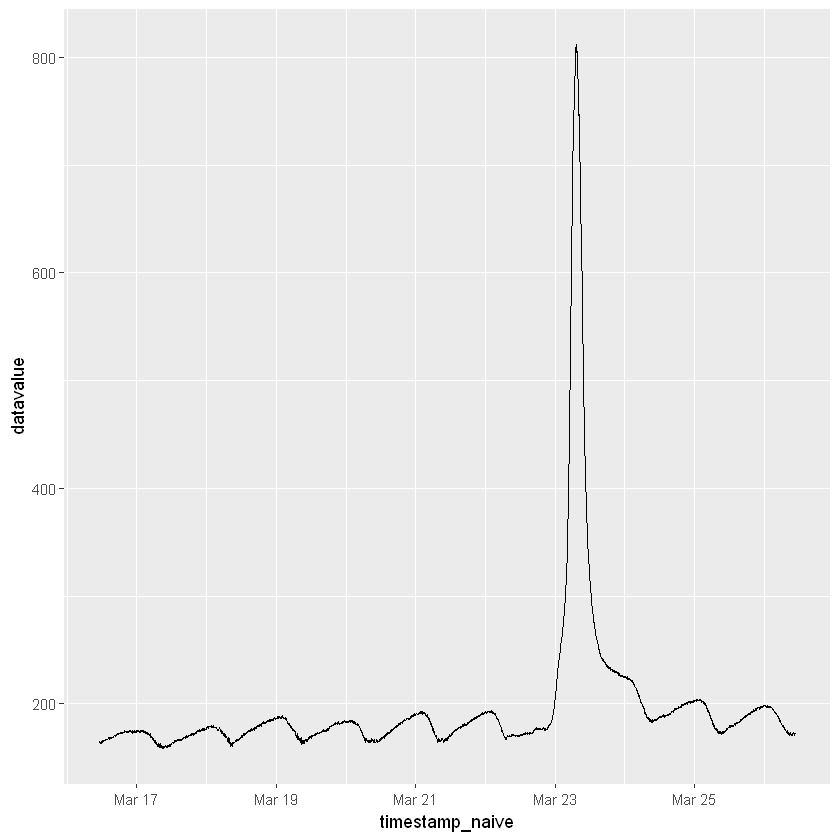

In [ ]:
# use the function
site_code <- "WCC017" #> add your site code here
variable_code <- "Decagon_CTD-10_Depth" #> add your variable code here, or use the UUID if you prefer
uuid <- "" #> add your UUID here, or use the variable code if you prefer
time_now <- as.POSIXct(Sys.time(), "UTC")
ten_days_seconds <- 10 * 24 * 60 * 60
start_date <- strftime(time_now - ten_days_seconds, "%Y-%m-%dT%H:%M:%SZ", tz = "UTC", usetz = FALSE)
end_date <- strftime(time_now + (60 * 60), "%Y-%m-%dT%H:%M:%SZ", tz = "UTC", usetz = FALSE)

monitormw_data <- get_monitormw_data(
  site_code = site_code,
  variable_code = variable_code,
  start_date = start_date,
  end_date = end_date
)

# create time series plot
p <- ggplot(monitormw_data, aes(x = timestamp_naive, y = datavalue)) +
  geom_line()

# display time series plot
p
